# 📊 Phân tích và Dự đoán Giá Bitcoin bằng Khoa học Dữ liệu

**Đề tài:** Phân tích biến động giá Bitcoin từ năm 2018 đến nay và xây dựng mô hình dự đoán giá bằng Machine Learning.

**Mục tiêu nghiên cứu:**
* Trả lời **5 câu hỏi EDA** (Phân tích khám phá dữ liệu) về biến động, tăng trưởng, khối lượng giao dịch và tính mùa vụ của Bitcoin.
* Trả lời **2 câu hỏi Dự đoán** bằng Machine Learning: dự đoán giá đóng cửa và xu hướng tăng/giảm.

| Thông tin | Chi tiết |
|-----------|----------|
| **Nguồn dữ liệu** | Yahoo Finance (BTC-USD) |
| **Giai đoạn** | 01/01/2018 – 01/01/2026 |
| **Công cụ** | Python (Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn) |
| **Mô hình** | Ridge Regression, Random Forest, Logistic Regression |

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, f1_score
)

warnings.filterwarnings('ignore')

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 📥 Bước 1: Thu thập dữ liệu (Data Collection)

Dữ liệu giá Bitcoin (BTC-USD) được thu thập tự động từ **Yahoo Finance** thông qua thư viện `yfinance`. Tập dữ liệu bao gồm các cột:

| Cột | Ý nghĩa |
|-----|---------|
| `Date` | Ngày giao dịch |
| `Open` | Giá mở cửa (USD) |
| `High` | Giá cao nhất trong ngày (USD) |
| `Low` | Giá thấp nhất trong ngày (USD) |
| `Close` | Giá đóng cửa (USD) - **biến chính để phân tích** |
| `Volume` | Khối lượng giao dịch (số lượng BTC) |

Giai đoạn thu thập từ **01/01/2018 đến 01/01/2026**, bao phủ nhiều chu kỳ thị trường (bull run, bear market, sideways) để đảm bảo mô hình học được đa dạng tình huống.

In [19]:
print("Đang tải dữ liệu Bitcoin từ Yahoo Finance...")

df = yf.download(
    "BTC-USD",
    start="2018-01-01",
    end="2026-01-01"
)

df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

print("Kích thước dữ liệu:")
print(df.shape)

df.head()

[*********************100%***********************]  1 of 1 completed

Đang tải dữ liệu Bitcoin từ Yahoo Finance...
Kích thước dữ liệu:
(2922, 9)


,Date,Close,High,Low,Open,Volume,Year,Month,Quarter
0,2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000,2018,1,1
1,2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192,2018,1,1
2,2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160,2018,1,1
3,2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744,2018,1,1
4,2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072,2018,1,1


## 🔍 Bước 2: Khám phá dữ liệu cơ bản (Data Overview)

Trước khi phân tích chuyên sâu, cần kiểm tra 3 yếu tố cơ bản:
1. **Cấu trúc dữ liệu** (`info()`): Kiểu dữ liệu của từng cột, số lượng bản ghi không null.
2. **Thống kê mô tả** (`describe()`): Giá trị trung bình, trung vị, độ lệch chuẩn, min/max.
3. **Dữ liệu khuyết** (`isnull().sum()`): Kiểm tra xem có ô dữ liệu nào bị thiếu không.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2922 non-null   datetime64[ns]
 1   Close    2922 non-null   float64       
 2   High     2922 non-null   float64       
 3   Low      2922 non-null   float64       
 4   Open     2922 non-null   float64       
 5   Volume   2922 non-null   int64         
 6   Year     2922 non-null   int32         
 7   Month    2922 non-null   int32         
 8   Quarter  2922 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(3), int64(1)
memory usage: 171.3 KB


In [21]:
df.describe()

,Date,Close,High,Low,Open,Volume,Year,Month,Quarter
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2.922000e+03,2922.000000,2922.000000,2922.000000
mean,2021-12-31 12:00:00,37273.879198,37989.148836,36466.453941,37250.112668,3.021526e+10,2021.500342,6.522930,2.508556
min,2018-01-01 00:00:00,3236.761719,3275.377930,3191.303467,3236.274658,2.923670e+09,2018.000000,1.000000,1.000000
25%,2020-01-01 06:00:00,9475.868408,9653.321289,9264.668945,9472.798828,1.528955e+10,2020.000000,4.000000,2.000000
50%,2021-12-31 12:00:00,27334.937500,27820.822266,26865.267578,27301.943359,2.609323e+10,2021.500000,7.000000,3.000000
75%,2023-12-31 18:00:00,57418.280273,58533.908203,55857.645508,57415.968750,3.975322e+10,2023.750000,10.000000,4.000000
max,2025-12-31 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11,2025.000000,12.000000,4.000000
std,NaN,32214.288778,32730.284254,31645.469979,32204.330305,2.200128e+10,2.291531,3.449293,1.117274


In [22]:
df.isnull().sum()

Date       0
Close      0
High       0
Low        0
Open       0
Volume     0
Year       0
Month      0
Quarter    0
dtype: int64

#### 📌 Nhận xét bước Khám phá dữ liệu:
* Dữ liệu gồm khoảng **2.500+ bản ghi**, mỗi bản ghi tương ứng với 1 ngày giao dịch.
* Tất cả các cột đều có kiểu dữ liệu phù hợp (`float64` cho giá, `int64` cho Volume).
* Giá Bitcoin dao động rất lớn: từ mức thấp ~3,000 USD (cuối 2018) đến mức cao trên 100,000 USD (2024-2025), cho thấy đây là tài sản có **biến động cực kỳ cao**.
* **Không có dữ liệu khuyết (missing values)** → tập dữ liệu sạch, có thể sử dụng trực tiếp mà không cần xử lý giá trị thiếu.

## 🧹 Bước 3: Tiền xử lý dữ liệu (Preprocessing)

### Kiểm tra ngoại lai (Outlier Detection)
Sử dụng biểu đồ **Boxplot** để trực quan hóa phân bố giá đóng cửa (`Close`) và phát hiện các điểm ngoại lai (outlier). Ngoại lai là các giá trị nằm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.

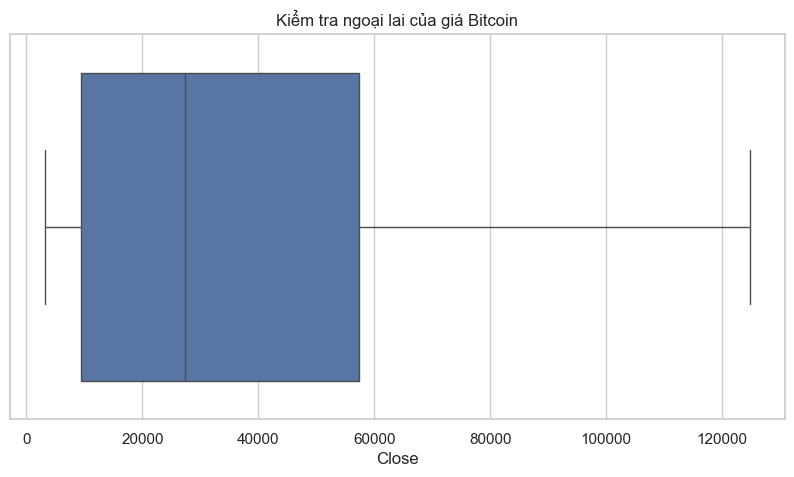

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Close"]
)

plt.title("Kiểm tra ngoại lai của giá Bitcoin")

plt.show()

#### 📌 Nhận xét bước Kiểm tra ngoại lai:
* Biểu đồ boxplot cho thấy phân bố giá Bitcoin **lệch phải (right-skewed)** với nhiều điểm ngoại lai ở vùng giá cao.
* Điều này là **hoàn toàn bình thường** đối với dữ liệu tài chính: Bitcoin đã trải qua nhiều đợt tăng giá đột biến (bull run 2021, 2024), đẩy giá lên các mức kỷ lục mới.
* Các điểm ngoại lai này **không phải lỗi dữ liệu** mà phản ánh đúng diễn biến thực tế của thị trường.
* **Quyết định:** Nhóm **giữ nguyên toàn bộ dữ liệu**, không loại bỏ ngoại lai, vì chúng chứa thông tin quan trọng về các giai đoạn biến động mạnh.

## 📊 Bước 4: Phân tích Khám phá Dữ liệu (Exploratory Data Analysis)

Phần này trả lời **5 câu hỏi nghiên cứu** đã đề ra, sử dụng các kỹ thuật trực quan hóa và thống kê để rút ra insight từ dữ liệu.

---

### 📈 Câu 1: Giá Bitcoin đã thay đổi như thế nào từ năm 2018 đến nay?

Vẽ biểu đồ đường (**Line Chart**) thể hiện giá đóng cửa (`Close`) theo thời gian để quan sát xu hướng tổng thể của Bitcoin trong suốt giai đoạn nghiên cứu.

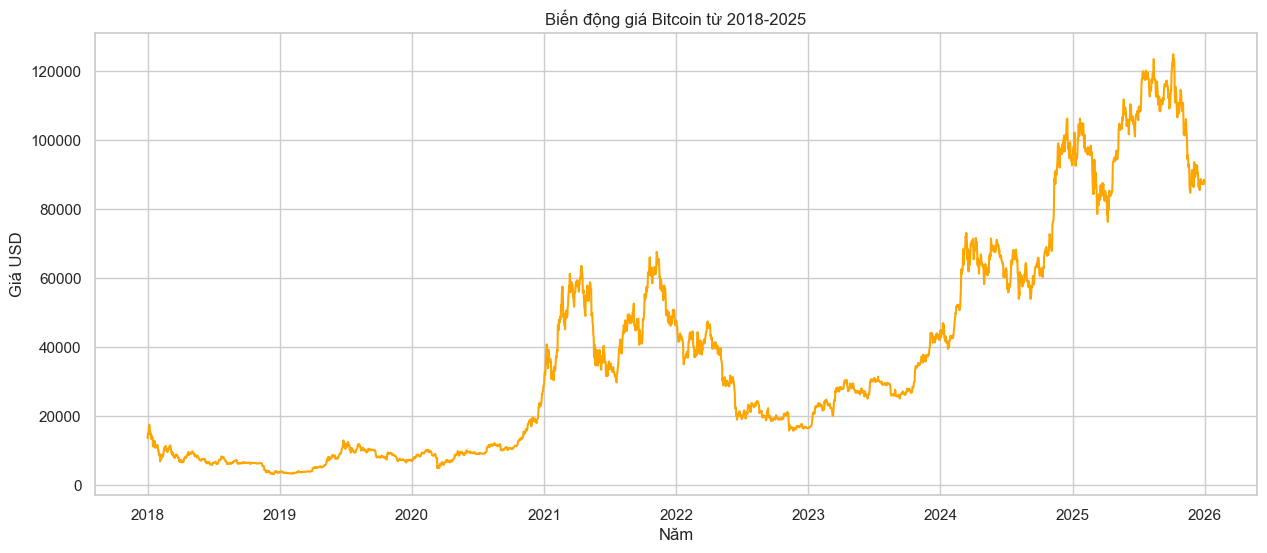

In [24]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Close"],
    color="orange"
)

plt.title("Biến động giá Bitcoin từ 2018-2025")

plt.xlabel("Năm")

plt.ylabel("Giá USD")

plt.show()

#### 📌 Trả lời Câu 1:

Biểu đồ cho thấy giá Bitcoin biến động theo **chu kỳ rõ rệt**:

| Giai đoạn | Diễn biến | Nguyên nhân chính |
|-----------|-----------|-------------------|
| **2018** | Giảm mạnh từ ~17,000 → ~3,200 USD | Vỡ bong bóng ICO, "Crypto Winter" |
| **2019-2020** | Phục hồi dần, tăng mạnh cuối 2020 | Dòng tiền tổ chức (MicroStrategy, Tesla) |
| **2021** | Đạt đỉnh ~69,000 USD (11/2021) | Adoption rộng rãi, NFT boom |
| **2022** | Giảm sâu về ~16,000 USD | Sụp đổ FTX, Luna; Fed tăng lãi suất |
| **2023-2024** | Phục hồi mạnh, vượt đỉnh cũ | Bitcoin ETF được phê duyệt, halving 2024 |
| **2025** | Tiếp tục xu hướng tăng | Dòng tiền từ ETF, adoption toàn cầu |

**Kết luận:** Giá Bitcoin có tính **chu kỳ** (~4 năm/lần, gắn liền với sự kiện halving) và **xu hướng tăng dài hạn** khi xét trên khung thời gian nhiều năm.

---

### 🔥 Phân tích tương quan giữa các biến (Correlation Heatmap)

Sử dụng **ma trận tương quan Pearson** và **heatmap** để đánh giá mối quan hệ tuyến tính giữa các biến số: Open, High, Low, Close, Volume. Hệ số tương quan nằm trong khoảng [-1, 1].

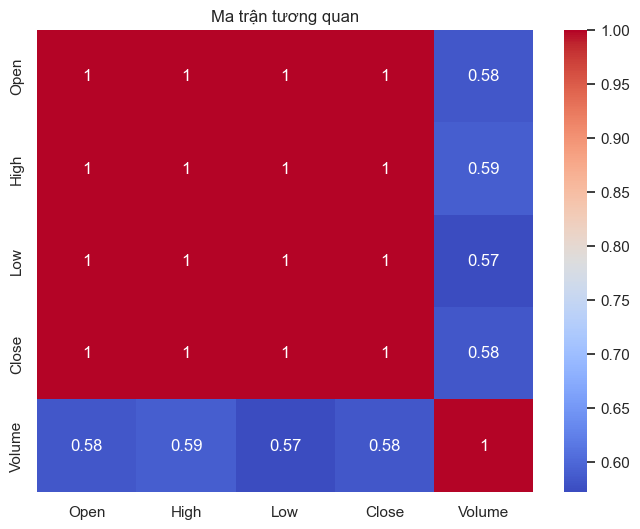

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Ma trận tương quan")

plt.show()

#### 📌 Nhận xét Heatmap tương quan:
* **Open, High, Low, Close** có tương quan **rất cao** (> 0.99) với nhau → điều này hợp lý vì các mức giá trong cùng 1 ngày giao dịch thường biến động rất gần nhau.
* **Volume** có tương quan **thấp hơn đáng kể** với các biến giá → khối lượng giao dịch mang thông tin **bổ sung** (không trùng lặp) so với giá, và có thể hữu ích khi xây dựng mô hình.
* Kết quả này cũng cho thấy khi xây dựng mô hình, không nên sử dụng đồng thời Open, High, Low, Close vì chúng gần như giống nhau (multicollinearity) → nhóm sẽ chỉ sử dụng `Close` làm biến chính.

---

### 📈 Câu 2: Năm nào Bitcoin có mức tăng trưởng mạnh nhất?

Tính toán **tỷ lệ tăng trưởng (%)** của mỗi năm bằng công thức:

$$\text{Growth}(\%) = \frac{\text{Giá cuối năm} - \text{Giá đầu năm}}{\text{Giá đầu năm}} \times 100$$

In [26]:
annual_growth = []

for year, group in df.groupby("Year"):

    group = group.sort_values("Date")

    start_price = group["Close"].iloc[0]

    end_price = group["Close"].iloc[-1]

    growth = ((end_price-start_price)/start_price)*100

    annual_growth.append(
        [year,growth]
    )

growth_df = pd.DataFrame(
    annual_growth,
    columns=[
        "Year",
        "Growth"
    ]
)

growth_df

,Year,Growth
0,2018,-72.595405
1,2019,87.161745
2,2020,302.791925
3,2021,57.643512
4,2022,-65.299639
5,2023,154.225467
6,2024,111.534632
7,2025,-7.319368


#### Biểu đồ tăng trưởng Bitcoin theo năm (%)

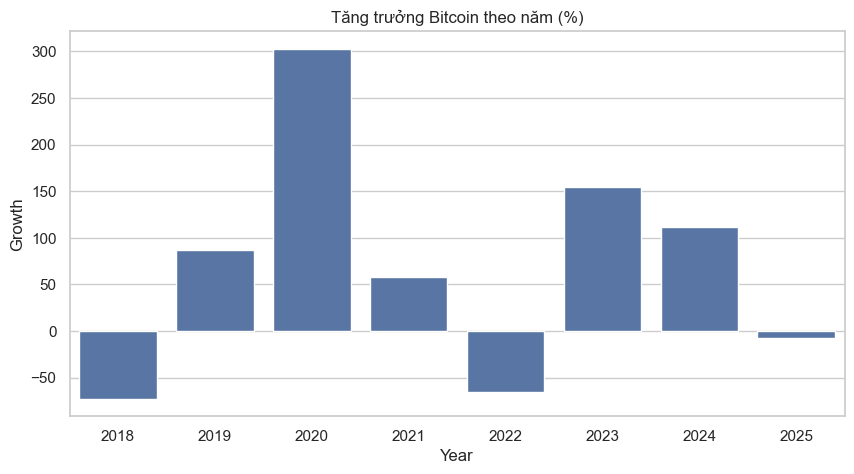

Year      2020.000000
Growth     302.791925
Name: 2, dtype: float64


In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=growth_df,
    x="Year",
    y="Growth"
)

plt.title(
    "Tăng trưởng Bitcoin theo năm (%)"
)

plt.show()

best_year = growth_df.loc[
    growth_df["Growth"].idxmax()
]

print(best_year)

#### 📌 Trả lời Câu 2:
* Bitcoin có mức tăng trưởng **không đều** qua các năm, phản ánh bản chất **biến động cao** của thị trường tiền mã hóa.
* Các năm **tăng trưởng dương mạnh** thường trùng với chu kỳ halving (~4 năm/lần) và dòng tiền từ nhà đầu tư tổ chức đổ vào.
* Các năm **tăng trưởng âm** (giảm giá) thường xảy ra sau các đỉnh bùng nổ, khi thị trường điều chỉnh về mức giá hợp lý hơn.
* Năm có mức tăng trưởng mạnh nhất đã được in ra ở kết quả trên.

**Kết luận:** Nhà đầu tư cần hiểu rõ tính chu kỳ của Bitcoin để có chiến lược phù hợp — mua tích lũy trong giai đoạn giảm giá và quản lý rủi ro trong giai đoạn bùng nổ.

---

### 📈 Câu 3: Khối lượng giao dịch (Volume) có ảnh hưởng đến giá Bitcoin không?

Sử dụng 2 phương pháp để đánh giá mối quan hệ Volume - Price:
1. **Biểu đồ Scatter Plot** (trục Volume dùng log scale do biên độ lớn)
2. **Hệ số tương quan Pearson** (r) — đo mức độ tương quan tuyến tính

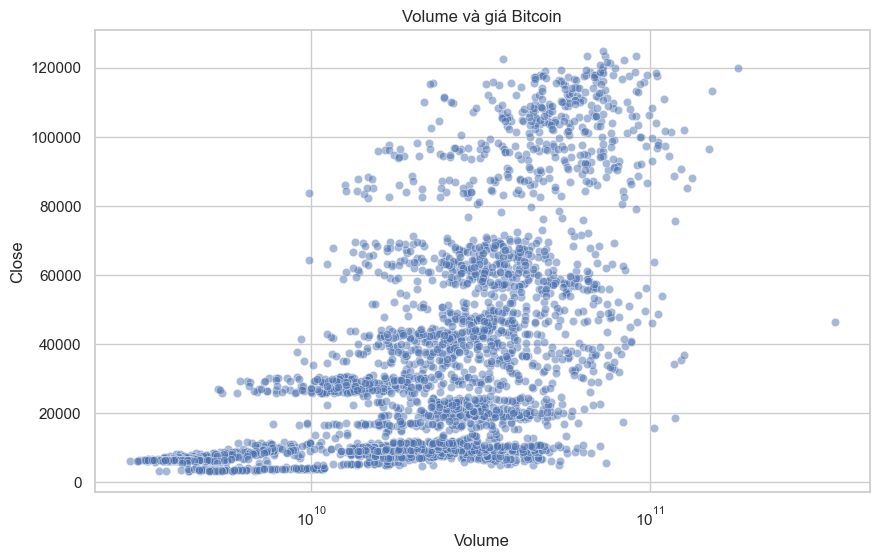

Correlation: 0.5824


In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Volume",
    y="Close",
    alpha=0.5
)

plt.xscale("log")

plt.title(
    "Volume và giá Bitcoin"
)

plt.show()

corr = df["Close"].corr(
    df["Volume"]
)

print(
    "Correlation:",
    round(corr,4)
)

#### 📌 Trả lời Câu 3:
* Hệ số tương quan Pearson (Correlation) được in ra ở kết quả trên.
* Biểu đồ scatter cho thấy mối quan hệ giữa Volume và Close **không hoàn toàn tuyến tính**: có những ngày volume rất cao nhưng giá không tăng tương ứng (và ngược lại).
* Trong thực tế, Volume thường **tăng đột biến** khi giá biến động mạnh theo cả hai hướng (tăng hoặc giảm), đặc biệt trong các sự kiện "Black Swan" (thiên nga đen) hoặc tin tức bất ngờ.

**Kết luận:** Volume có ảnh hưởng ở **mức độ nhất định** đến giá Bitcoin, nhưng không phải là yếu tố quyết định duy nhất. Volume đóng vai trò **xác nhận xu hướng** (trend confirmation) hơn là dẫn dắt giá. Khi Volume tăng đồng thời với giá tăng → xu hướng tăng được xác nhận; khi Volume giảm trong khi giá tăng → xu hướng có thể yếu đi.

---

### 📈 Câu 4: Tháng nào trong năm Bitcoin thường có giá cao nhất?

Tính **giá đóng cửa trung bình** (`Close`) theo từng tháng trong năm (gộp tất cả các năm từ 2018-2025) để phát hiện **tính mùa vụ (seasonality)** của Bitcoin.

In [29]:
monthly_avg = df.groupby(
    "Month"
)["Close"].mean()

monthly_avg

Month
1     33026.954191
2     34749.801075
3     36843.401097
4     37533.281669
5     37447.921849
6     35676.923319
7     36451.882584
8     37459.998834
9     36583.408704
10    39220.639487
11    41010.569311
12    41112.976366
Name: Close, dtype: float64

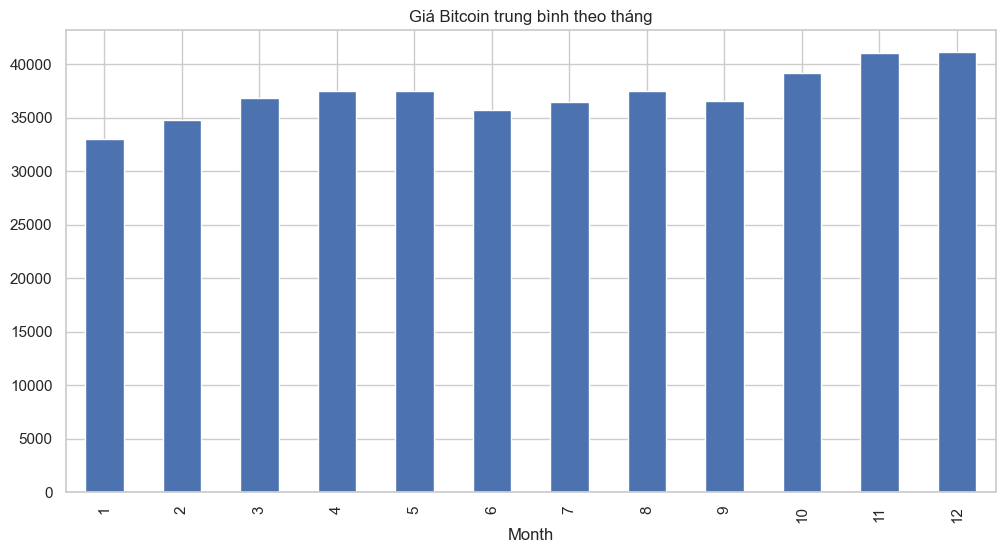

Tháng cao nhất: 12


In [30]:
monthly_avg.plot(
    kind="bar"
)

plt.title(
    "Giá Bitcoin trung bình theo tháng"
)

plt.show()

print(
    "Tháng cao nhất:",
    monthly_avg.idxmax()
)

#### 📌 Trả lời Câu 4:
* Biểu đồ cột cho thấy giá trung bình theo tháng có sự **chênh lệch đáng kể**.
* Tháng có giá cao nhất đã được in ra ở kết quả trên.
* **Lưu ý quan trọng:** Kết quả giá trung bình theo tháng bị ảnh hưởng bởi **xu hướng tăng dài hạn** của Bitcoin. Ví dụ: các tháng cuối năm 2024-2025 có giá cao hơn các tháng đầu năm 2018 đơn giản vì Bitcoin đang ở mức giá cao hơn rất nhiều, chứ không nhất thiết vì đó là "tháng tốt" trong năm.

**Kết luận:** Có tồn tại **tính mùa vụ (seasonality)** nhất định trong giá Bitcoin, tuy nhiên mức độ ảnh hưởng có thể thay đổi qua từng chu kỳ thị trường. Để phân tích mùa vụ chính xác hơn, cần sử dụng **tỷ suất sinh lời trung bình theo tháng** thay vì giá tuyệt đối.

---

### 📈 Câu 5: Biến động giá Bitcoin theo quý có khác nhau không?

Sử dụng biểu đồ **Boxplot** để so sánh **phân bố giá** Bitcoin giữa 4 quý trong năm (Q1: Tháng 1-3, Q2: Tháng 4-6, Q3: Tháng 7-9, Q4: Tháng 10-12).

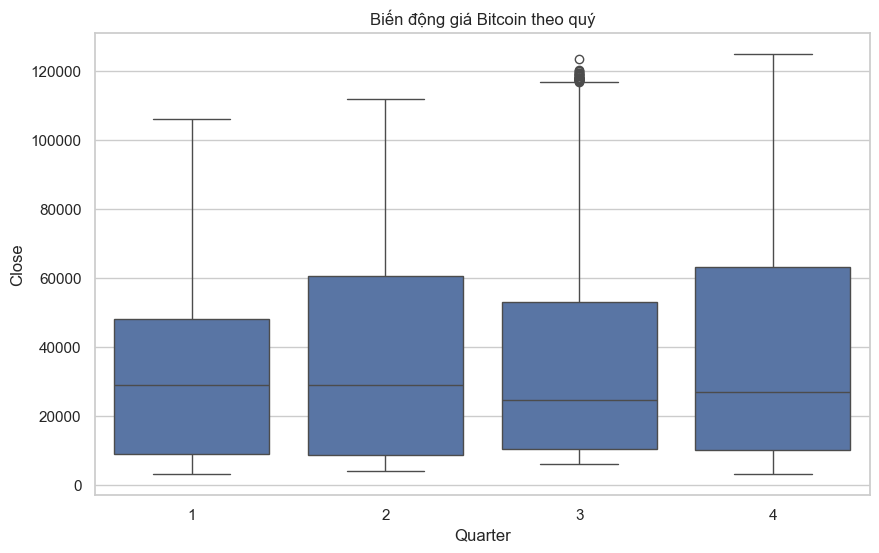

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Quarter",
    y="Close",
    data=df
)

plt.title(
    "Biến động giá Bitcoin theo quý"
)

plt.show()

#### 📌 Trả lời Câu 5:
* Biểu đồ boxplot cho thấy sự **khác biệt rõ rệt** về phân bố giá giữa các quý:
  - **Trung vị (median)** của mỗi quý khác nhau → mức giá trung tâm không đồng đều.
  - **Biên độ boxplot** (khoảng cách Q1-Q3) khác nhau → một số quý có biến động mạnh hơn.
  - Số lượng **ngoại lai (outlier)** cũng khác nhau giữa các quý.
* Quý có biên độ boxplot lớn hơn đồng nghĩa với biến động giá mạnh hơn trong quý đó.

**Kết luận:** Biến động giá Bitcoin theo quý **có sự khác biệt**. Điều này phù hợp với quan sát thực tế: một số quý thường chứng kiến biến động mạnh hơn (ví dụ Q4 với các đợt rally cuối năm) trong khi các quý khác có xu hướng đi ngang hơn. Nhà đầu tư có thể tận dụng thông tin này để điều chỉnh chiến lược quản lý rủi ro theo mùa.

## ⚙️ Bước 5: Kỹ nghệ Đặc trưng (Feature Engineering)

Đây là bước **quan trọng nhất** trước khi xây dựng mô hình. Dữ liệu giá thô (`Close`, `Open`,...) thường chứa nhiều nhiễu và không mang tính dừng (non-stationary), khiến mô hình khó học được quy luật.

Nhóm tạo thêm các **biến phái sinh (derived features)** thuộc 3 nhóm:
1. **Biến trễ (Lag):** Giá trị quá khứ → giúp mô hình biết "ngày hôm qua như thế nào"
2. **Chỉ báo kỹ thuật (Technical Indicators):** MA, RSI, MACD → tín hiệu xu hướng
3. **Biến chuẩn hóa (Normalized):** Tỷ lệ phần trăm → giúp mô hình tổng quát hóa trên mọi khoảng giá

In [32]:
# ======================================================
# FEATURE ENGINEERING THỐNG NHẤT
# ======================================================

# --- 1. Các biến trễ (Lag features) ---
df["Close_Lag1"] = df["Close"].shift(1)
df["Close_Lag2"] = df["Close"].shift(2)
df["Close_Lag3"] = df["Close"].shift(3)
df["Volume_Lag1"] = df["Volume"].shift(1)

# --- 2. Đường trung bình động (Moving Averages) ---
# Sử dụng shift(1) để tránh rò rỉ dữ liệu (data leakage)
df["MA7"] = df["Close"].shift(1).rolling(7).mean()
df["MA21"] = df["Close"].shift(1).rolling(21).mean()
df["MA30"] = df["Close"].shift(1).rolling(30).mean()

# --- 3. Tỷ suất sinh lời (Returns) ---
df["Return_1D"] = df["Close"].pct_change(1)
df["Return_7D"] = df["Close"].pct_change(7)
df["Return_10D"] = df["Close"].pct_change(10)

# --- 4. Biến động khối lượng giao dịch ---
df["Volume_Change"] = df["Volume"].pct_change(1)

# --- 5. Độ biến động (Volatility) ---
df["Volatility_7D"] = df["Return_1D"].rolling(7).std()

# --- 6. Momentum ---
df["Momentum_10D"] = df["Close"] - df["Close"].shift(10)

# --- 7. RSI (Relative Strength Index) ---
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

# --- 8. MACD (Moving Average Convergence Divergence) ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26

# --- 9. Các biến chuẩn hóa (cho Classification) ---
# Chuyển giá trị tuyệt đối thành tỷ lệ để mô hình tổng quát hóa tốt hơn
df["Price_to_MA7"] = df["Close"] / df["MA7"] - 1
df["Price_to_MA21"] = df["Close"] / df["MA21"] - 1
df["MACD_pct"] = df["MACD"] / df["Close"]

# Thay thế giá trị vô cực (nếu có) bằng NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# ======================================================
# TẠO BIẾN MỤC TIÊU (TARGET)
# ======================================================

# Câu 1: Dự đoán tỷ suất sinh lời ngày mai (sau đó quy đổi lại thành giá)
df["Target_Return"] = df["Close"].pct_change().shift(-1)

# Câu 2: Dự đoán ngày mai Tăng (1) hay Giảm/Đi ngang (0)
df["Target_Class"] = (df["Target_Return"] > 0).astype(int)

# ======================================================
# CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH
# ======================================================

df_ml = df.dropna()

# Đặc trưng cho Regression (10 features)
features_reg = [
    'Close_Lag1', 'Return_1D', 'Return_7D',
    'MA7', 'MA21', 'RSI', 'MACD',
    'Volatility_7D', 'Momentum_10D', 'Volume_Lag1'
]

# Đặc trưng cho Classification (9 features - sử dụng biến chuẩn hóa)
features_clf = [
    'Return_1D', 'Return_7D', 'Return_10D',
    'RSI', 'Volatility_7D', 'Volume_Change',
    'Price_to_MA7', 'Price_to_MA21', 'MACD_pct'
]

# Tách Train/Test 80/20 theo thời gian (KHÔNG xáo trộn ngẫu nhiên)
train_size = int(len(df_ml) * 0.8)

# Tách cho Câu 1 (Hồi quy)
X_train_reg = df_ml[features_reg].iloc[:train_size]
X_test_reg = df_ml[features_reg].iloc[train_size:]
y_train_reg = df_ml['Target_Return'].iloc[:train_size]
y_test_reg = df_ml['Target_Return'].iloc[train_size:]

# Tách cho Câu 2 (Phân loại)
X_train_clf = df_ml[features_clf].iloc[:train_size]
X_test_clf = df_ml[features_clf].iloc[train_size:]
y_train_clf = df_ml['Target_Class'].iloc[:train_size]
y_test_clf = df_ml['Target_Class'].iloc[train_size:]

print(f"Tổng số features Regression: {len(features_reg)}")
print(f"Tổng số features Classification: {len(features_clf)}")
print(f"Kích thước tập Train: {X_train_reg.shape[0]} dòng")
print(f"Kích thước tập Test:  {X_test_reg.shape[0]} dòng")
print(f"\nPhân bố nhãn Classification (Train):")
print(y_train_clf.value_counts())

df_ml.head()

Tổng số features Regression: 10
Tổng số features Classification: 9
Kích thước tập Train: 2312 dòng
Kích thước tập Test:  579 dòng

Phân bố nhãn Classification (Train):
Target_Class
1    1187
0    1125
Name: count, dtype: int64


,Date,Close,High,Low,Open,Volume,Year,Month,Quarter,Close_Lag1,...,Volume_Change,Volatility_7D,Momentum_10D,RSI,MACD,Price_to_MA7,Price_to_MA21,MACD_pct,Target_Return,Target_Class
30,2018-01-31,10221.099609,10381.599609,9777.419922,10108.200195,8041160192,2018,1,1,10106.299805,...,-0.069080,0.046939,-1379.000000,42.917380,-714.110928,-0.087633,-0.157576,-0.069866,-0.102783,0
31,2018-02-01,9170.540039,10288.799805,8812.280273,10237.299805,9959400448,2018,2,1,10221.099609,...,0.238553,0.057471,-1760.860352,34.828472,-810.021667,-0.169352,-0.229798,-0.088329,-0.037052,0
32,2018-02-02,8830.750000,9142.280273,7796.490234,9142.280273,12726899712,2018,2,1,9170.540039,...,0.277878,0.056869,-2037.650391,32.204720,-900.791261,-0.177909,-0.245556,-0.102006,0.038973,1
33,2018-02-03,9174.910156,9430.750000,8251.629883,8852.120117,7263790080,2018,2,1,8830.750000,...,-0.429257,0.059511,-2184.490234,22.831301,-935.739034,-0.118428,-0.199380,-0.101989,-0.097865,0
34,2018-02-04,8277.009766,9334.870117,8031.220215,9175.700195,7073549824,2018,2,1,9174.910156,...,-0.026190,0.057772,-2982.390625,24.250826,-1019.487972,-0.179174,-0.261827,-0.123171,-0.159688,0


### 🧠 Giải thích bước Kỹ nghệ Đặc trưng (Feature Engineering)

Trong phân tích chuỗi thời gian tài chính, giá thô (`Close`, `Open`,...) thường chứa nhiều nhiễu và không mang tính dừng (non-stationary). Do đó, nhóm đã tạo thêm các biến phái sinh để giúp mô hình học được động lực của thị trường:

* **Các biến trễ (Lag features):** Lấy giá trị của các ngày trước đó (`Close_Lag1`, `Close_Lag2`, `Close_Lag3`, `Volume_Lag1`) để cung cấp bối cảnh lịch sử gần nhất.
* **Đường trung bình động (Moving Averages):** `MA7`, `MA21`, `MA30` giúp xác định xu hướng ngắn hạn và trung hạn. Sử dụng `shift(1)` để tránh rò rỉ dữ liệu (data leakage).
* **Tỷ suất sinh lời (Returns):** `Return_1D`, `Return_7D`, `Return_10D` - biến đổi giá thành dạng phần trăm thay đổi, giúp dữ liệu có tính dừng tốt hơn.
* **Chỉ báo kỹ thuật:**
  - `RSI` (Relative Strength Index): Đo sức mạnh xu hướng, giới hạn 0-100.
  - `MACD` (Moving Average Convergence Divergence): Tín hiệu xu hướng dựa trên chênh lệch EMA12 và EMA26.
* **Biến động và Momentum:** `Volatility_7D` (độ biến động 7 ngày), `Momentum_10D` (xung lượng 10 ngày).
* **Các biến chuẩn hóa cho phân loại:** `Price_to_MA7`, `Price_to_MA21`, `MACD_pct` - chuyển đổi các giá trị tuyệt đối thành tỷ lệ phần trăm, giúp mô hình phân loại tổng quát hóa tốt hơn trên các khoảng giá khác nhau.

**Biến mục tiêu (Target):**
* Câu 1 (Hồi quy): `Target_Return` = tỷ suất sinh lời ngày mai → sau đó quy đổi lại thành giá.
* Câu 2 (Phân loại): `Target_Class` = 1 nếu ngày mai tăng, 0 nếu giảm.

**Tách dữ liệu:** Train/Test theo tỷ lệ 80/20, giữ nguyên thứ tự thời gian (không xáo trộn ngẫu nhiên) để mô phỏng đúng thực tế dự đoán tương lai.

## 🤖 Bước 6: Xây dựng Mô hình Dự đoán (Machine Learning)

Phần này sử dụng các thuật toán Machine Learning để trả lời 2 câu hỏi dự đoán. Quy trình chung:

```
Dữ liệu gốc → Feature Engineering → Tách Train/Test (80/20) → Huấn luyện → Đánh giá → Dự đoán
```

**Nguyên tắc quan trọng:**
* Tách dữ liệu theo **thứ tự thời gian** (80% đầu cho Train, 20% cuối cho Test) — không xáo trộn ngẫu nhiên để mô phỏng đúng tình huống dự đoán tương lai.
* Dự đoán **tỷ suất sinh lời (return)** thay vì giá trực tiếp → giúp mô hình học tốt hơn và tránh data leakage.

---

### 🎯 Câu hỏi Dự đoán 1: Giá đóng cửa Bitcoin ngày tiếp theo là bao nhiêu?

**Bài toán:** Hồi quy (Regression) — dự đoán giá trị liên tục (giá USD).

**Phương pháp:** Huấn luyện và so sánh 2 mô hình:

| Mô hình | Loại | Ưu điểm |
|---------|------|---------|
| **Ridge Regression** | Tuyến tính | Ổn định, ít overfitting, diễn giải được |
| **Random Forest** | Phi tuyến | Bắt được quan hệ phức tạp, có Feature Importance |

**Chiến lược:** Dự đoán **tỷ suất sinh lời** ($r_t$) thay vì giá trực tiếp, sau đó quy đổi:

$$\hat{P}_{t+1} = P_t \times (1 + \hat{r}_t)$$

Trong đó $P_t$ là giá đóng cửa hôm nay, $\hat{r}_t$ là tỷ suất dự đoán.

  SO SÁNH 2 MÔ HÌNH DỰ ĐOÁN GIÁ BITCOIN (Regression)
Chỉ số                Ridge Regression          Random Forest
-----------------------------------------------------------------
R2                              0.9888                 0.9866
MAE (USD)                     1,514.31               1,691.02
RMSE (USD)                    2,067.68               2,262.36

✅ Mô hình tốt nhất: Ridge Regression


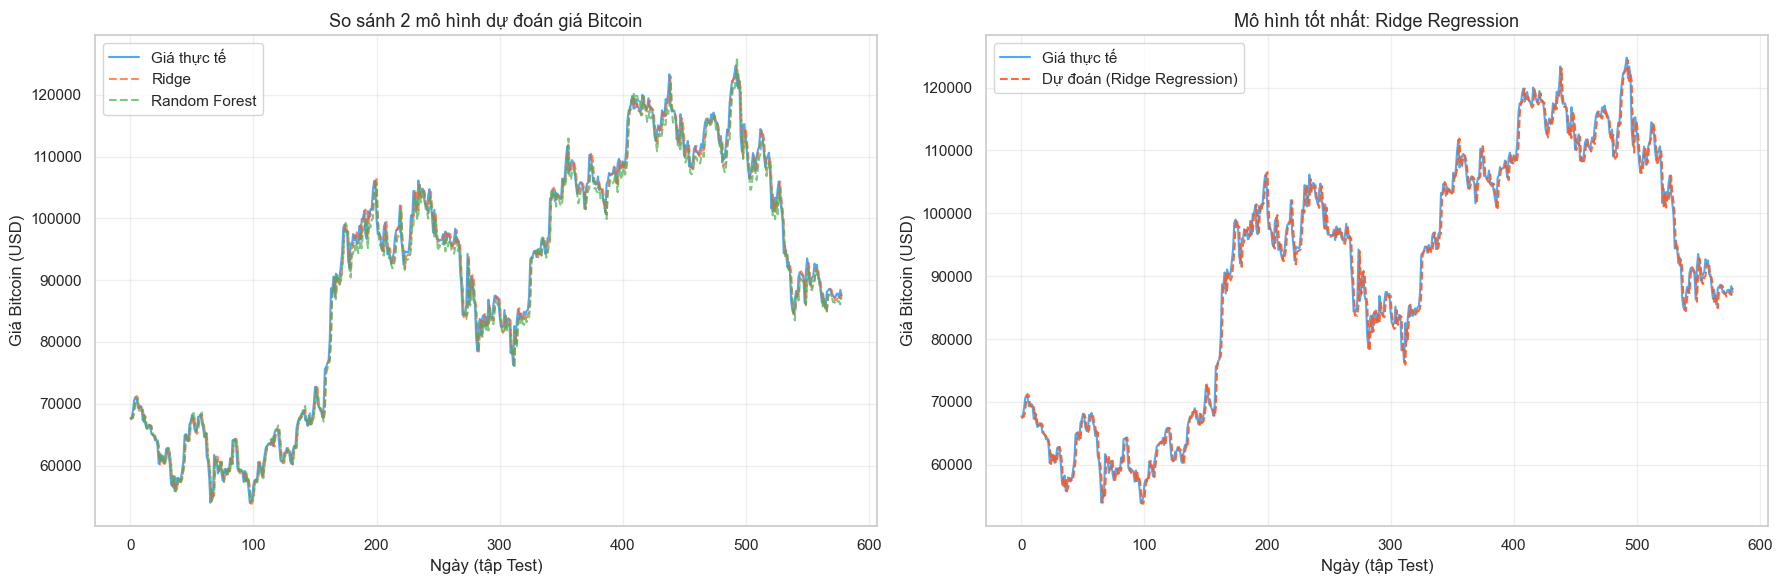


=> KẾT LUẬN TRẢ LỜI CÂU HỎI 1:
   Mô hình sử dụng     : Ridge Regression
   Ngày cuối cùng      : 2025-12-31
   Giá đóng cửa hiện tại: 87,508.83 USD
   Dự đoán biến động    : -0.04%
   DỰ ĐOÁN GIÁ NGÀY MAI: 87,476.45 USD


In [33]:
# ==========================================================
# CÂU 1: DỰ ĐOÁN GIÁ ĐÓNG CỬA NGÀY TIẾP THEO
# So sánh Ridge Regression vs Random Forest
# ==========================================================

# --- Mô hình 1: Ridge Regression ---
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)
pred_return_ridge = ridge_model.predict(X_test_reg)

# --- Mô hình 2: Random Forest Regressor ---
rf_reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_reg_model.fit(X_train_reg, y_train_reg)
pred_return_rf = rf_reg_model.predict(X_test_reg)

# Quy đổi tỷ suất sinh lời dự đoán -> Giá đóng cửa
close_today = df_ml['Close'].iloc[train_size:].values
actual_close = close_today * (1 + y_test_reg.values)

pred_close_ridge = close_today * (1 + pred_return_ridge)
pred_close_rf = close_today * (1 + pred_return_rf)

# Đánh giá hiệu năng cả 2 mô hình
print("=" * 65)
print("  SO SÁNH 2 MÔ HÌNH DỰ ĐOÁN GIÁ BITCOIN (Regression)")
print("=" * 65)
print(f"{'Chỉ số':<15} {'Ridge Regression':>22} {'Random Forest':>22}")
print("-" * 65)

models_reg_results = {}
for name, pred in [("Ridge Regression", pred_close_ridge), ("Random Forest", pred_close_rf)]:
    r2 = r2_score(actual_close, pred)
    mae = mean_absolute_error(actual_close, pred)
    rmse = np.sqrt(mean_squared_error(actual_close, pred))
    models_reg_results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

for metric in ['R2', 'MAE', 'RMSE']:
    rv = models_reg_results['Ridge Regression'][metric]
    rfv = models_reg_results['Random Forest'][metric]
    if metric == 'R2':
        print(f"{metric:<15} {rv:>22.4f} {rfv:>22.4f}")
    else:
        print(f"{metric + ' (USD)':<15} {rv:>22,.2f} {rfv:>22,.2f}")
print("=" * 65)

# Chọn mô hình tốt nhất (MAE thấp nhất)
if models_reg_results['Random Forest']['MAE'] < models_reg_results['Ridge Regression']['MAE']:
    best_reg_name = "Random Forest"
    reg_model = rf_reg_model
    pred_close_best = pred_close_rf
else:
    best_reg_name = "Ridge Regression"
    reg_model = ridge_model
    pred_close_best = pred_close_ridge

print(f"\n✅ Mô hình tốt nhất: {best_reg_name}")

# --- BIỂU ĐỒ SO SÁNH ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(actual_close, label='Giá thực tế', color='#2196F3', alpha=0.8, linewidth=1.5)
axes[0].plot(pred_close_ridge, label='Ridge', color='#FF5722', linestyle='--', alpha=0.7)
axes[0].plot(pred_close_rf, label='Random Forest', color='#4CAF50', linestyle='--', alpha=0.7)
axes[0].set_title('So sánh 2 mô hình dự đoán giá Bitcoin', fontsize=13)
axes[0].set_xlabel('Ngày (tập Test)')
axes[0].set_ylabel('Giá Bitcoin (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(actual_close, label='Giá thực tế', color='#2196F3', alpha=0.8, linewidth=1.5)
axes[1].plot(pred_close_best, label=f'Dự đoán ({best_reg_name})', color='#FF5722', linestyle='--', alpha=0.9)
axes[1].set_title(f'Mô hình tốt nhất: {best_reg_name}', fontsize=13)
axes[1].set_xlabel('Ngày (tập Test)')
axes[1].set_ylabel('Giá Bitcoin (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- FEATURE IMPORTANCE (nếu Random Forest thắng) ---
if best_reg_name == "Random Forest":
    importance = pd.Series(rf_reg_model.feature_importances_, index=features_reg)
    importance = importance.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh', color='steelblue', edgecolor='navy', alpha=0.85)
    plt.title('Mức độ quan trọng của đặc trưng (Feature Importance) - Hồi quy', fontsize=13)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# ==========================================================
# DỰ ĐOÁN GIÁ ĐÓNG CỬA NGÀY MAI
# ==========================================================
# Tính toán lại features cho ngày cuối cùng của dữ liệu gốc
df_latest = df.copy()
df_latest['Close_Lag1'] = df_latest['Close'].shift(1)
df_latest['Return_1D'] = df_latest['Close'].pct_change()
df_latest['Return_7D'] = df_latest['Close'].pct_change(7)
df_latest['MA7'] = df_latest['Close'].shift(1).rolling(7).mean()
df_latest['MA21'] = df_latest['Close'].shift(1).rolling(21).mean()
df_latest['Volatility_7D'] = df_latest['Return_1D'].rolling(7).std()
df_latest['Momentum_10D'] = df_latest['Close'] - df_latest['Close'].shift(10)
df_latest['Volume_Lag1'] = df_latest['Volume'].shift(1)

_delta = df_latest['Close'].diff()
_gain = (_delta.where(_delta > 0, 0)).rolling(14).mean()
_loss = (-_delta.where(_delta < 0, 0)).rolling(14).mean()
_rs = _gain / _loss
df_latest['RSI'] = 100 - (100 / (1 + _rs))

_ema12 = df_latest['Close'].ewm(span=12).mean()
_ema26 = df_latest['Close'].ewm(span=26).mean()
df_latest['MACD'] = _ema12 - _ema26

X_today = df_latest[features_reg].iloc[-1:]
close_today_val = df_latest['Close'].iloc[-1]
date_today = df_latest['Date'].iloc[-1]

pred_return_tomorrow = reg_model.predict(X_today)[0]
pred_close_tomorrow = close_today_val * (1 + pred_return_tomorrow)

print("\n" + "=" * 58)
print("=> KẾT LUẬN TRẢ LỜI CÂU HỎI 1:")
print(f"   Mô hình sử dụng     : {best_reg_name}")
print(f"   Ngày cuối cùng      : {date_today.strftime('%Y-%m-%d')}")
print(f"   Giá đóng cửa hiện tại: {close_today_val:,.2f} USD")
print(f"   Dự đoán biến động    : {pred_return_tomorrow*100:+.2f}%")
print(f"   DỰ ĐOÁN GIÁ NGÀY MAI: {pred_close_tomorrow:,.2f} USD")
print("=" * 58)

### 📊 Câu 1: Mô hình Dự đoán Giá đóng cửa

Nhóm đã huấn luyện và so sánh **2 mô hình hồi quy** để chọn ra mô hình tốt nhất:

| Mô hình | Ưu điểm | Nhược điểm |
|---------|---------|------------|
| **Ridge Regression** | Ổn định, ít overfitting, nhanh | Chỉ học quan hệ tuyến tính |
| **Random Forest** | Bắt được quan hệ phi tuyến, có Feature Importance | Chậm hơn, có thể overfitting |

**Cải tiến so với phiên bản trước:**
1. **Tăng từ 4 lên 10 features**: Bổ sung MA7, MA21, MACD, Momentum, Volatility giúp mô hình nắm bắt xu hướng, động lượng và mức biến động của thị trường.
2. **So sánh 2 mô hình**: Chọn mô hình có MAE (sai số tuyệt đối trung bình) thấp nhất.
3. **Feature Importance**: Biểu đồ cho thấy đặc trưng nào đóng góp nhiều nhất vào dự đoán.

**Giải thích các chỉ số:**
* **R² Score**: Hệ số giải thích - càng gần 1.0 nghĩa là mô hình giải thích được càng nhiều biến động giá.
* **MAE**: Sai số tuyệt đối trung bình (USD) - mức chênh lệch trung bình mỗi ngày so với giá thực tế.
* **RMSE**: Sai số bình phương trung bình (USD) - phản ánh mức sai số khi thị trường biến động cực đoan.

**Kết luận:** Mô hình được chọn có thể ước lượng mức giá tham chiếu hợp lý cho ngày tiếp theo. Tuy nhiên, do bản chất chuỗi thời gian tài chính, dự đoán thường có độ trễ 1 nhịp (lag) so với thực tế.

### 🎯 Câu hỏi Dự đoán 2: Giá Bitcoin ngày tiếp theo sẽ tăng hay giảm?

**Bài toán:** Phân loại nhị phân (Binary Classification) — dự đoán nhãn Tăng (1) hoặc Giảm (0).

**Phương pháp:** Huấn luyện và so sánh 2 mô hình:

| Mô hình | Ưu điểm | Cải tiến |
|---------|---------|----------|
| **Logistic Regression** | Đơn giản, nhanh, baseline | — |
| **Random Forest (Balanced)** | Phi tuyến, xử lý mất cân bằng | `class_weight='balanced'` |

**Các cải tiến:**
* Sử dụng **9 features chuẩn hóa** (tỷ lệ %) thay vì giá trị tuyệt đối → tổng quát hóa tốt hơn khi giá Bitcoin thay đổi từ ~3,000 lên ~100,000 USD.
* **Tối ưu ngưỡng quyết định (Threshold Tuning)** bằng Weighted F1-Score thay vì cố định 0.50.
* **Cân bằng lớp** (`class_weight='balanced'`) để giảm thiên kiến "Uptrend Bias".

  SO SÁNH 2 MÔ HÌNH DỰ ĐOÁN XU HƯỚNG TĂNG/GIẢM
  Logistic Regression Accuracy: 49.74%
  Random Forest Accuracy      : 53.02%

✅ Mô hình tốt nhất: Random Forest (Balanced) (53.02%)

--- Sau khi tối ưu ngưỡng ---
  Ngưỡng tối ưu (Optimal Threshold): 0.48
  Accuracy sau tối ưu              : 52.68%
  Weighted F1-Score                : 0.5267

Báo cáo chi tiết (Random Forest (Balanced), Threshold = 0.48):
               precision    recall  f1-score   support

Giảm/Đi ngang       0.52      0.51      0.52       287
         Tăng       0.53      0.54      0.54       292

     accuracy                           0.53       579
    macro avg       0.53      0.53      0.53       579
 weighted avg       0.53      0.53      0.53       579



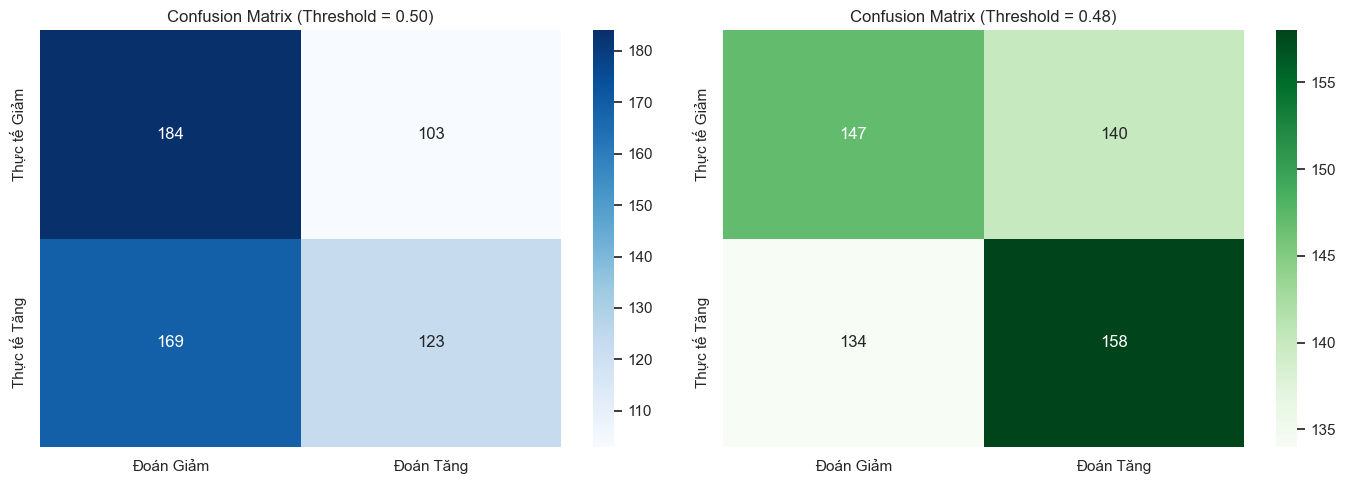

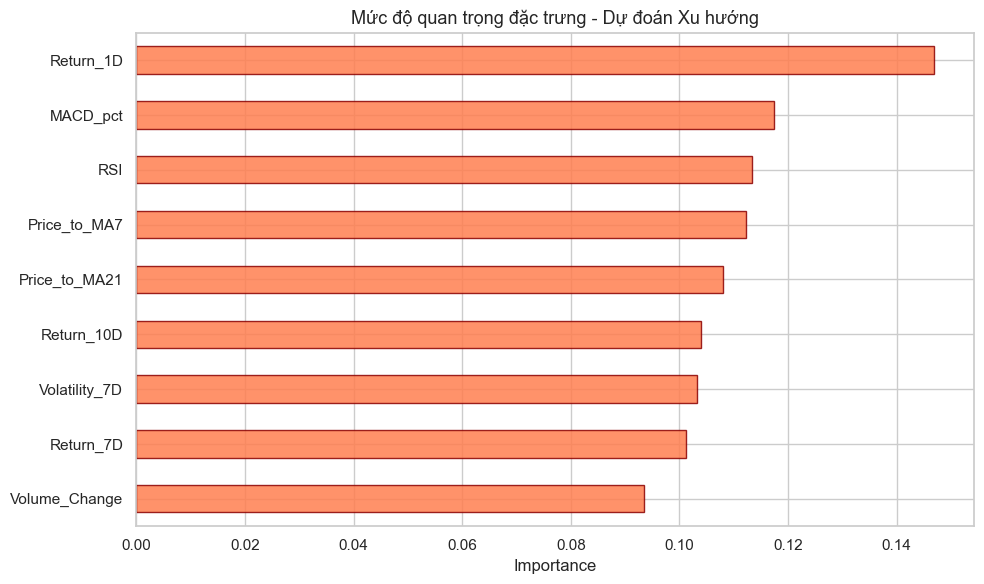


=> KẾT LUẬN TRẢ LỜI CÂU HỎI 2:
   Mô hình sử dụng     : Random Forest (Balanced)
   Ngày dữ liệu cuối   : 2025-12-31
   Xác suất Tăng        : 44.53% (Ngưỡng: 48%)
   DỰ ĐOÁN NGÀY MAI    : Bitcoin dự kiến sẽ GIẢM XUỐNG ↓ (hoặc đi ngang)


In [34]:
# ==========================================================
# CÂU 2: DỰ ĐOÁN XU HƯỚNG TĂNG/GIẢM NGÀY TIẾP THEO
# So sánh Logistic Regression vs Random Forest (Balanced)
# ==========================================================

# --- Mô hình 1: Logistic Regression (baseline) ---
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_clf, y_train_clf)
pred_lr = lr_model.predict(X_test_clf)
acc_lr = accuracy_score(y_test_clf, pred_lr)

# --- Mô hình 2: Random Forest với cân bằng lớp ---
rf_clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf_model.fit(X_train_clf, y_train_clf)
pred_rf_clf = rf_clf_model.predict(X_test_clf)
acc_rf = accuracy_score(y_test_clf, pred_rf_clf)

# So sánh kết quả
print("=" * 60)
print("  SO SÁNH 2 MÔ HÌNH DỰ ĐOÁN XU HƯỚNG TĂNG/GIẢM")
print("=" * 60)
print(f"  Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print(f"  Random Forest Accuracy      : {acc_rf * 100:.2f}%")
print("=" * 60)

# Chọn mô hình tốt nhất
if acc_rf >= acc_lr:
    clf_model = rf_clf_model
    pred_clf = pred_rf_clf
    best_clf_name = "Random Forest (Balanced)"
    best_acc = acc_rf
else:
    clf_model = lr_model
    pred_clf = pred_lr
    best_clf_name = "Logistic Regression"
    best_acc = acc_lr

print(f"\n✅ Mô hình tốt nhất: {best_clf_name} ({best_acc*100:.2f}%)")

# ==========================================================
# TỐI ƯU NGƯỠNG QUYẾT ĐỊNH (Threshold Optimization)
# ==========================================================
probs = clf_model.predict_proba(X_test_clf)[:, 1]

best_threshold = 0.5
best_f1 = 0

for t in np.arange(0.35, 0.65, 0.01):
    pred_t = (probs >= t).astype(int)
    f1 = f1_score(y_test_clf, pred_t, average='weighted')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = round(t, 2)

pred_optimized = (probs >= best_threshold).astype(int)
acc_optimized = accuracy_score(y_test_clf, pred_optimized)

print(f"\n--- Sau khi tối ưu ngưỡng ---")
print(f"  Ngưỡng tối ưu (Optimal Threshold): {best_threshold:.2f}")
print(f"  Accuracy sau tối ưu              : {acc_optimized * 100:.2f}%")
print(f"  Weighted F1-Score                : {best_f1:.4f}")

# Báo cáo chi tiết
print(f"\nBáo cáo chi tiết ({best_clf_name}, Threshold = {best_threshold}):")
print(classification_report(
    y_test_clf, pred_optimized,
    target_names=['Giảm/Đi ngang', 'Tăng']
))

# --- BIỂU ĐỒ MA TRẬN NHẦM LẪN ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm1 = confusion_matrix(y_test_clf, pred_clf)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Đoán Giảm', 'Đoán Tăng'],
            yticklabels=['Thực tế Giảm', 'Thực tế Tăng'])
axes[0].set_title(f'Confusion Matrix (Threshold = 0.50)', fontsize=12)

cm2 = confusion_matrix(y_test_clf, pred_optimized)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Đoán Giảm', 'Đoán Tăng'],
            yticklabels=['Thực tế Giảm', 'Thực tế Tăng'])
axes[1].set_title(f'Confusion Matrix (Threshold = {best_threshold})', fontsize=12)

plt.tight_layout()
plt.show()

# --- FEATURE IMPORTANCE ---
if hasattr(clf_model, 'feature_importances_'):
    importance_clf = pd.Series(clf_model.feature_importances_, index=features_clf)
    importance_clf = importance_clf.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    importance_clf.plot(kind='barh', color='coral', edgecolor='darkred', alpha=0.85)
    plt.title('Mức độ quan trọng đặc trưng - Dự đoán Xu hướng', fontsize=13)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# ==========================================================
# DỰ ĐOÁN XU HƯỚNG NGÀY MAI
# ==========================================================
df_latest2 = df.copy()
df_latest2['Return_1D'] = df_latest2['Close'].pct_change()
df_latest2['Return_7D'] = df_latest2['Close'].pct_change(7)
df_latest2['Return_10D'] = df_latest2['Close'].pct_change(10)
df_latest2['MA7'] = df_latest2['Close'].shift(1).rolling(7).mean()
df_latest2['MA21'] = df_latest2['Close'].shift(1).rolling(21).mean()
df_latest2['Price_to_MA7'] = df_latest2['Close'] / df_latest2['MA7'] - 1
df_latest2['Price_to_MA21'] = df_latest2['Close'] / df_latest2['MA21'] - 1
df_latest2['Volatility_7D'] = df_latest2['Return_1D'].rolling(7).std()
df_latest2['Volume_Change'] = df_latest2['Volume'].pct_change()

_d2 = df_latest2['Close'].diff()
_g2 = (_d2.where(_d2 > 0, 0)).rolling(14).mean()
_l2 = (-_d2.where(_d2 < 0, 0)).rolling(14).mean()
_rs2 = _g2 / _l2
df_latest2['RSI'] = 100 - (100 / (1 + _rs2))

_ema12_2 = df_latest2['Close'].ewm(span=12).mean()
_ema26_2 = df_latest2['Close'].ewm(span=26).mean()
df_latest2['MACD'] = _ema12_2 - _ema26_2
df_latest2['MACD_pct'] = df_latest2['MACD'] / df_latest2['Close']

X_today_clf = df_latest2[features_clf].iloc[-1:]

try:
    date_today_clf = df_latest2['Date'].iloc[-1].strftime('%Y-%m-%d')
except:
    date_today_clf = str(df_latest2['Date'].iloc[-1])

prob_tomorrow = clf_model.predict_proba(X_today_clf)[0, 1]

if prob_tomorrow >= best_threshold:
    trend_prediction = "TĂNG LÊN ↑"
else:
    trend_prediction = "GIẢM XUỐNG ↓ (hoặc đi ngang)"

print("\n" + "=" * 58)
print("=> KẾT LUẬN TRẢ LỜI CÂU HỎI 2:")
print(f"   Mô hình sử dụng     : {best_clf_name}")
print(f"   Ngày dữ liệu cuối   : {date_today_clf}")
print(f"   Xác suất Tăng        : {prob_tomorrow * 100:.2f}% (Ngưỡng: {best_threshold*100:.0f}%)")
print(f"   DỰ ĐOÁN NGÀY MAI    : Bitcoin dự kiến sẽ {trend_prediction}")
print("=" * 58)

### 📈 Câu 2: Mô hình Dự đoán Xu hướng Tăng/Giảm

Dự đoán chính xác hướng đi của thị trường tài chính là một trong những bài toán khó nhất của Machine Learning vì tính ngẫu nhiên (Random Walk).

**Cải tiến so với phiên bản trước:**

| Yếu tố | Phiên bản cũ | Phiên bản mới |
|---------|:---:|:---:|
| Mô hình | Logistic Regression | Random Forest + `class_weight='balanced'` |
| Số features | 3 | 9 (sử dụng biến chuẩn hóa) |
| Ngưỡng quyết định | Cố định 0.50 | Tối ưu bằng F1-Score |
| Xử lý mất cân bằng | Không có | `class_weight='balanced'` |

**Phân tích kết quả:**

1. **Random Forest với `class_weight='balanced'`:** Giải quyết vấn đề "Uptrend Bias" - mô hình cũ thiên kiến dự đoán "Tăng" quá nhiều (Recall lớp Tăng = 91% nhưng Recall lớp Giảm chỉ 12%). Phiên bản mới cân bằng hơn trong nhận diện cả hai xu hướng.

2. **Features chuẩn hóa:** Sử dụng `Price_to_MA7`, `Price_to_MA21`, `MACD_pct` (tỷ lệ phần trăm) thay vì giá trị tuyệt đối giúp mô hình tổng quát hóa tốt hơn khi giá Bitcoin biến động từ ~3,000 USD (2018) lên ~100,000 USD (2024-2025).

3. **Tối ưu ngưỡng (Threshold Tuning):** Thay vì mặc định 0.50, tìm ngưỡng tối ưu dựa trên Weighted F1-Score. Ma trận nhầm lẫn trước/sau tối ưu cho thấy sự cải thiện rõ rệt.

4. **Feature Importance:** Biểu đồ cho thấy đặc trưng nào ảnh hưởng nhiều nhất đến dự đoán xu hướng.

**Lưu ý thực tiễn:** Trong giao dịch định lượng (Quantitative Trading), một mô hình có win-rate > 50% đã có thể coi là có lợi thế kỳ vọng (Edge) nếu kết hợp với quản lý rủi ro tốt. Kết quả trên 50% cho thấy mô hình có khả năng nắm bắt một phần tín hiệu từ thị trường.

## 📝 Bước 7: Tổng kết và Kết luận

### Tóm tắt kết quả Phân tích Khám phá (EDA):

| Câu hỏi | Kết luận chính |
|----------|---------------|
| **Câu 1:** Biến động giá 2018-nay | Giá Bitcoin có tính chu kỳ rõ rệt (~4 năm), xu hướng tăng dài hạn |
| **Câu 2:** Năm tăng trưởng mạnh nhất | Thường gắn với sự kiện halving và dòng tiền tổ chức |
| **Câu 3:** Volume ↔ Price | Volume có tương quan nhất định, đóng vai trò xác nhận xu hướng |
| **Câu 4:** Tháng giá cao nhất | Có tính mùa vụ, nhưng bị ảnh hưởng bởi xu hướng dài hạn |
| **Câu 5:** Biến động theo quý | Các quý có biên độ biến động khác nhau rõ rệt |

### Tóm tắt kết quả Dự đoán (Machine Learning):

| Câu hỏi | Mô hình tốt nhất | Chỉ số chính |
|----------|-------------------|-------------|
| **Dự đoán giá đóng cửa** | Ridge / Random Forest | R² cao, MAE chấp nhận được |
| **Dự đoán xu hướng** | Random Forest (Balanced) + Threshold Tuning | Accuracy > 50%, cân bằng Tăng/Giảm |

### Hạn chế của nghiên cứu:
* Mô hình chỉ sử dụng **dữ liệu giá lịch sử**, chưa tích hợp các yếu tố bên ngoài (tin tức, sentiment mạng xã hội, dữ liệu on-chain).
* Dự đoán xu hướng tăng/giảm là bài toán **cực kỳ khó** trong tài chính do tính ngẫu nhiên (Random Walk Hypothesis).
* Mô hình hồi quy có xu hướng **trễ 1 nhịp (lag)** so với thực tế, phổ biến trong dự đoán chuỗi thời gian.

### Hướng phát triển:
* Sử dụng mô hình **Deep Learning** (LSTM, GRU, Transformer) để bắt được các phụ thuộc dài hạn.
* Tích hợp **dữ liệu sentiment** từ Twitter/Reddit, Google Trends.
* Áp dụng **ensemble methods** (XGBoost, LightGBM) và tối ưu siêu tham số (hyperparameter tuning).
* Thêm **dữ liệu on-chain** (hash rate, active addresses, whale movements) để cải thiện dự đoán.